In [30]:
import numpy as np
import pandas as pd
import ast

In [31]:
df1 = pd.read_csv("preprocessed_data_s1.csv")
df2 = pd.read_csv("preprocessed_data_s2.csv")
df = pd.concat([df1, df2], axis=0)

In [32]:
df.head(5)

,Unnamed: 0,text_id,annotators_id,text,initial_paragraph,topic,is_noise_or_spam_text,related_to_election_2024,toxicity,polarized,...,agreement_is_noise_or_spam_text,agreement_related_to_election_2024,agreement_toxicity,agreement_polarized,agreement_profanity_obscenity,agreement_threat_incitement_to_violence,agreement_insults,agreement_identity_attack,agreement_sexually_explicit,cleaned_text
0,27,1-1022,"['10', '18']",Video Adanya Beras Palsu Asal China Beredar di...,"Liputan6.com, Jakarta - Beredar di media sosia...",Tionghoa,0,0,0,1,...,True,True,False,True,True,True,True,False,True,Video Adanya Beras Palsu Asal China Beredar di...
1,28,1-1023,"['10', '18']",Para Pemuda Tiongkok RRC Akan Membanjiri Posis...,“PARA PEMUDA CINA AKAN MEMBANJIRI PEGAWAI NEGE...,UNKNOWN,0,0,0,1,...,True,True,False,True,True,True,True,False,True,Para Pemuda Tiongkok RRC Akan Membanjiri Posis...
2,29,1-1024,"['10', '18']",Prabowo bersama TNI Turun Tangan Bela Rakyat R...,"WOW! PRABOWO, SBY & GATOT NURMANTYO BERSAMA TN...",Tionghoa,0,0,0,1,...,True,True,False,True,True,True,True,False,True,Prabowo bersama TNI Turun Tangan Bela Rakyat R...
3,43,1-1037,"['10', '18']",Relawan Tionghoa Kalbar “All Out” Dukung Ganja...,NaN,Tionghoa,0,1,0,1,...,True,True,True,True,True,True,True,True,True,Relawan Tionghoa Kalbar “All Out” Dukung Ganja...
4,52,1-1045,"['10', '18', '32']","Dukung Ganjar, Etnis Tionghoa Singgung Pemimpi...",NaN,Tionghoa,0,1,0,1,...,True,True,False,False,True,True,True,False,True,"Dukung Ganjar, Etnis Tionghoa Singgung Pemimpi..."


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3936 entries, 0 to 1967
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Unnamed: 0                               3936 non-null   int64 
 1   text_id                                  3936 non-null   object
 2   annotators_id                            3936 non-null   object
 3   text                                     3936 non-null   object
 4   initial_paragraph                        211 non-null    object
 5   topic                                    3936 non-null   object
 6   is_noise_or_spam_text                    3936 non-null   int64 
 7   related_to_election_2024                 3936 non-null   int64 
 8   toxicity                                 3936 non-null   int64 
 9   polarized                                3936 non-null   int64 
 10  profanity_obscenity                      3936 non-null   int64 
 

In [ ]:
from openai import OpenAI
import pandas as pd
import json
import time

client = OpenAI(api_key="sk-proj-")

In [39]:
def classify_toxic(text):

    prompt = f"""
Kamu adalah model klasifikasi teks berbahasa Indonesia.

Tugas:
Tentukan apakah teks berikut termasuk:

- toxic:
Mengandung hinaan, ujaran kebencian,
serangan identitas, ancaman,
profanitas, ujaran seksual eksplisit,
atau bahasa menyerang.

- non_toxic:
Tidak mengandung unsur di atas.

Balas HANYA dengan:

toxic

atau

non_toxic


Contoh:

Teks:
"Hari ini cuacanya bagus"

Output:
non_toxic


Teks:
"Dasar goblok lu"

Output:
toxic


Teks:
"Aku mau makan siang"

Output:
non_toxic


Teks:
"Mata lu buta anjing"

Output:
toxic


Sekarang klasifikasikan:

Teks:
{text}

Output:
"""

    response = client.responses.create(
        model="gpt-5.4-mini",
        input=prompt
    )

    return response.output_text.strip()

In [40]:
def classify_multilabel(text):

    prompt = f"""
Kamu adalah model klasifikasi hate speech Indonesia.

Label:

- insults
- identity_attack
- profanity_obscenity
- sexually_explicit
- threat_incitement_to_violence

Output HARUS JSON list.

Teks:
{text}

Output:
"""

    response = client.responses.create(
        model="gpt-5.4-mini",
        input=prompt
    )

    return response.output_text

In [41]:
import json

def classify_2stage(text):
    try:

        stage1 = classify_toxic(text).strip().lower()

        if stage1 == "non_toxic":
            return {
                "toxic": "non_toxic",
                "labels": []
            }

        labels = classify_multilabel(text)

        # kalau output JSON string
        if isinstance(labels, str):
            try:
                labels = json.loads(labels)
            except:
                labels = []

        # normalize format labels
        if isinstance(labels, dict):
            labels = [labels.get("label")]

        elif (
            isinstance(labels, list)
            and len(labels) > 0
            and isinstance(labels[0], dict)
        ):
            labels = [
                x.get("label")
                for x in labels
                if "label" in x
            ]

        elif not isinstance(labels, list):
            labels = []

        # buang None
        labels = [x for x in labels if x]

        return {
            "toxic": "toxic",
            "labels": labels
        }

    except Exception as e:
        return {
            "toxic": None,
            "labels": [],
            "error": str(e)
        }

In [42]:
text = """
MATA MU BUTA ANJING
KAU JAWA TOLOL
"""

hasil = classify_2stage(text)

print(hasil)

{'toxic': None, 'labels': [], 'error': "Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}"}


In [11]:
import json, os, time
from tqdm.notebook import tqdm

predictions = json.load(open("predictions2.json")) if os.path.exists("predictions.json") else []

for text in tqdm(df['cleaned_text'].iloc[len(predictions):], desc="Classifying"):

    try:
        predictions.append(
            classify_2stage(text)
        )

    except Exception as e:
        predictions.append({
            "toxic":None,
            "labels":[],
            "error":str(e)
        })

    json.dump(
        predictions,
        open("predictions.json","w"),
        ensure_ascii=False
    )

    time.sleep(1)

Classifying:   0%|          | 0/3936 [00:00<?, ?it/s]

In [44]:
df['pred_toxic'] = [
    x['toxic']
    for x in predictions
]

df['pred_labels'] = [
    x['labels']
    for x in predictions
]

In [45]:
print(
    df['pred_toxic']
    .value_counts(
        dropna=False
    )
)
print(
    df['pred_labels']
    .value_counts(
        dropna=False
    )
)

pred_toxic
None         2286
non_toxic    1169
toxic         481
Name: count, dtype: int64
pred_labels
[]                                                                                3457
[identity_attack]                                                                  214
[insults]                                                                           90
[threat_incitement_to_violence]                                                     50
[insults, identity_attack]                                                          40
[identity_attack, insults]                                                          30
[identity_attack, threat_incitement_to_violence]                                    26
[insults, identity_attack, threat_incitement_to_violence]                            6
[profanity_obscenity]                                                                6
[insults, identity_attack, profanity_obscenity]                                      5
[insults, profanity_obsceni

In [25]:
from sklearn.metrics import classification_report

df['true_toxic'] = df[
    'toxicity'
].map({
    1: 'toxic',
    0: 'non_toxic'
})

df['pred_toxic'] = df[
    'pred_toxic'
].apply(lambda x:x
    if x in ['toxic', 'non_toxic']
    else 'non_toxic'
)

print(
    classification_report(
        df['true_toxic'],
        df['pred_toxic']
    )
)

              precision    recall  f1-score   support

   non_toxic       0.44      0.76      0.56      2000
       toxic       0.00      0.00      0.00      1936

    accuracy                           0.39      3936
   macro avg       0.22      0.38      0.28      3936
weighted avg       0.22      0.39      0.28      3936



In [26]:
def create_true_labels(row):

    labels = []

    if row['insults'] == 1:
        labels.append('insults')

    if row['identity_attack'] == 1:
        labels.append(
            'identity_attack'
        )

    if row[
        'profanity_obscenity'
    ] == 1:

        labels.append(
            'profanity_obscenity'
        )

    if row[
        'threat_incitement_to_violence'
    ] == 1:

        labels.append(
            'threat_incitement_to_violence'
        )

    if row[
        'sexually_explicit'
    ] == 1:

        labels.append(
            'sexually_explicit'
        )

    return labels


df['true_labels'] = df.apply(
    create_true_labels,
    axis=1
)

In [27]:
label_cols = [
    'insults',
    'identity_attack',
    'profanity_obscenity',
    'threat_incitement_to_violence',
    'sexually_explicit'
]

df['true_labels'] = df.apply(
    lambda row:
    [
        col
        for col in label_cols
        if row[col] == 1
    ],
    axis=1
)

In [28]:
def clean_pred_labels(x):

    cleaned = []

    if isinstance(x, list):

        for item in x:

            if isinstance(item, str):
                cleaned.append(item)

            elif (
                isinstance(item, dict)
                and 'label' in item
            ):
                cleaned.append(
                    item['label']
                )

    return cleaned


df['pred_labels'] = (
    df['pred_labels']
    .apply(clean_pred_labels)
)

In [29]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report


mlb = MultiLabelBinarizer()

y_true = mlb.fit_transform(
    df['true_labels']
)

y_pred = mlb.transform(
    df['pred_labels']
)

print(
classification_report(
    y_true,
    y_pred,
    target_names=mlb.classes_,
    zero_division=0
))

                               precision    recall  f1-score   support

              identity_attack       0.00      0.00      0.00       726
                      insults       0.00      0.00      0.00       705
          profanity_obscenity       0.00      0.00      0.00       238
            sexually_explicit       0.00      0.00      0.00        42
threat_incitement_to_violence       0.01      0.01      0.01        83

                    micro avg       0.00      0.00      0.00      1794
                    macro avg       0.00      0.00      0.00      1794
                 weighted avg       0.00      0.00      0.00      1794
                  samples avg       0.00      0.00      0.00      1794



In [23]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(
    y_true,
    y_pred
)

print("Subset Accuracy:", acc)

Subset Accuracy: 0.0


# gpt-4.1-mini

## Stage 1

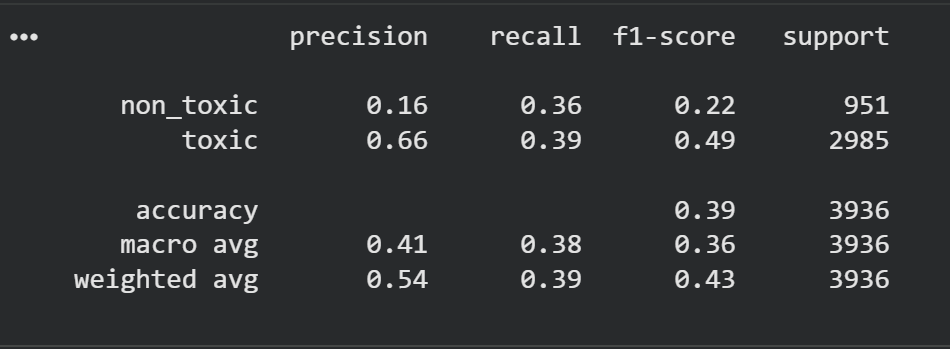

## Stage 2

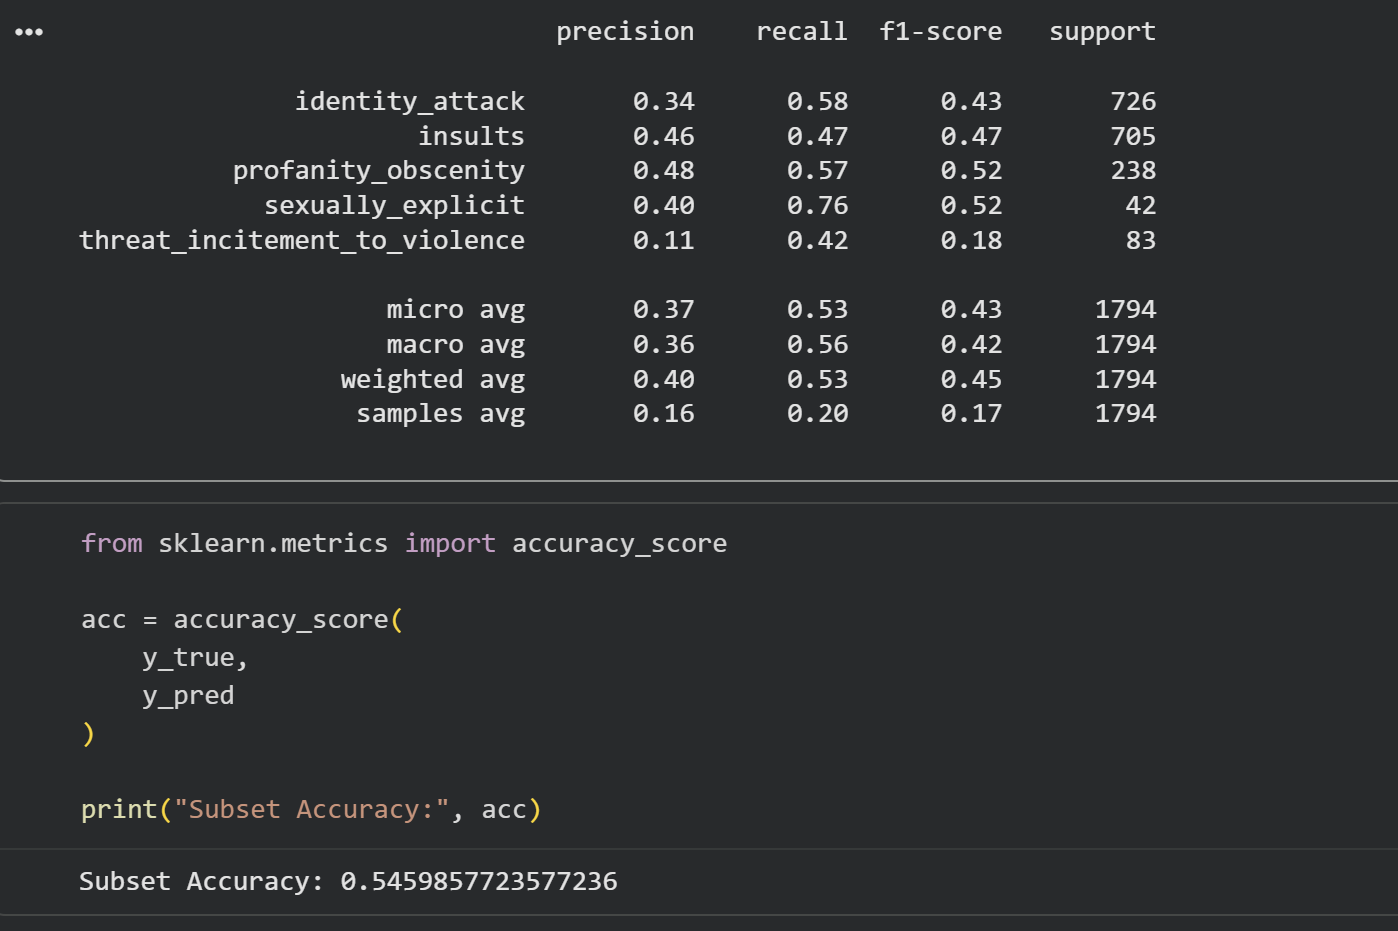


# GPT-5.4-mini

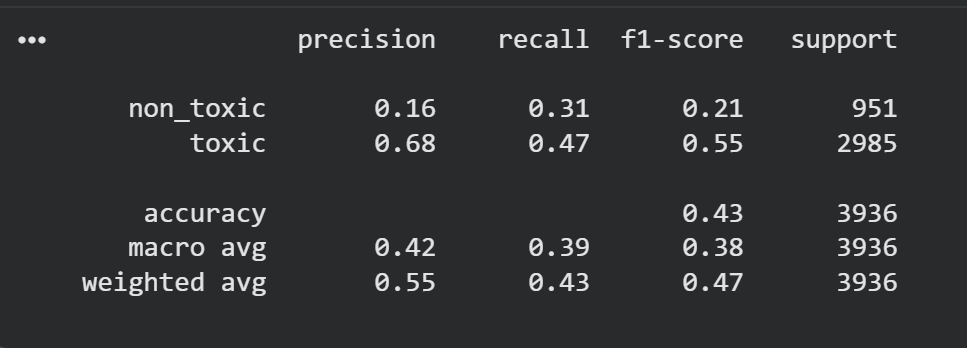
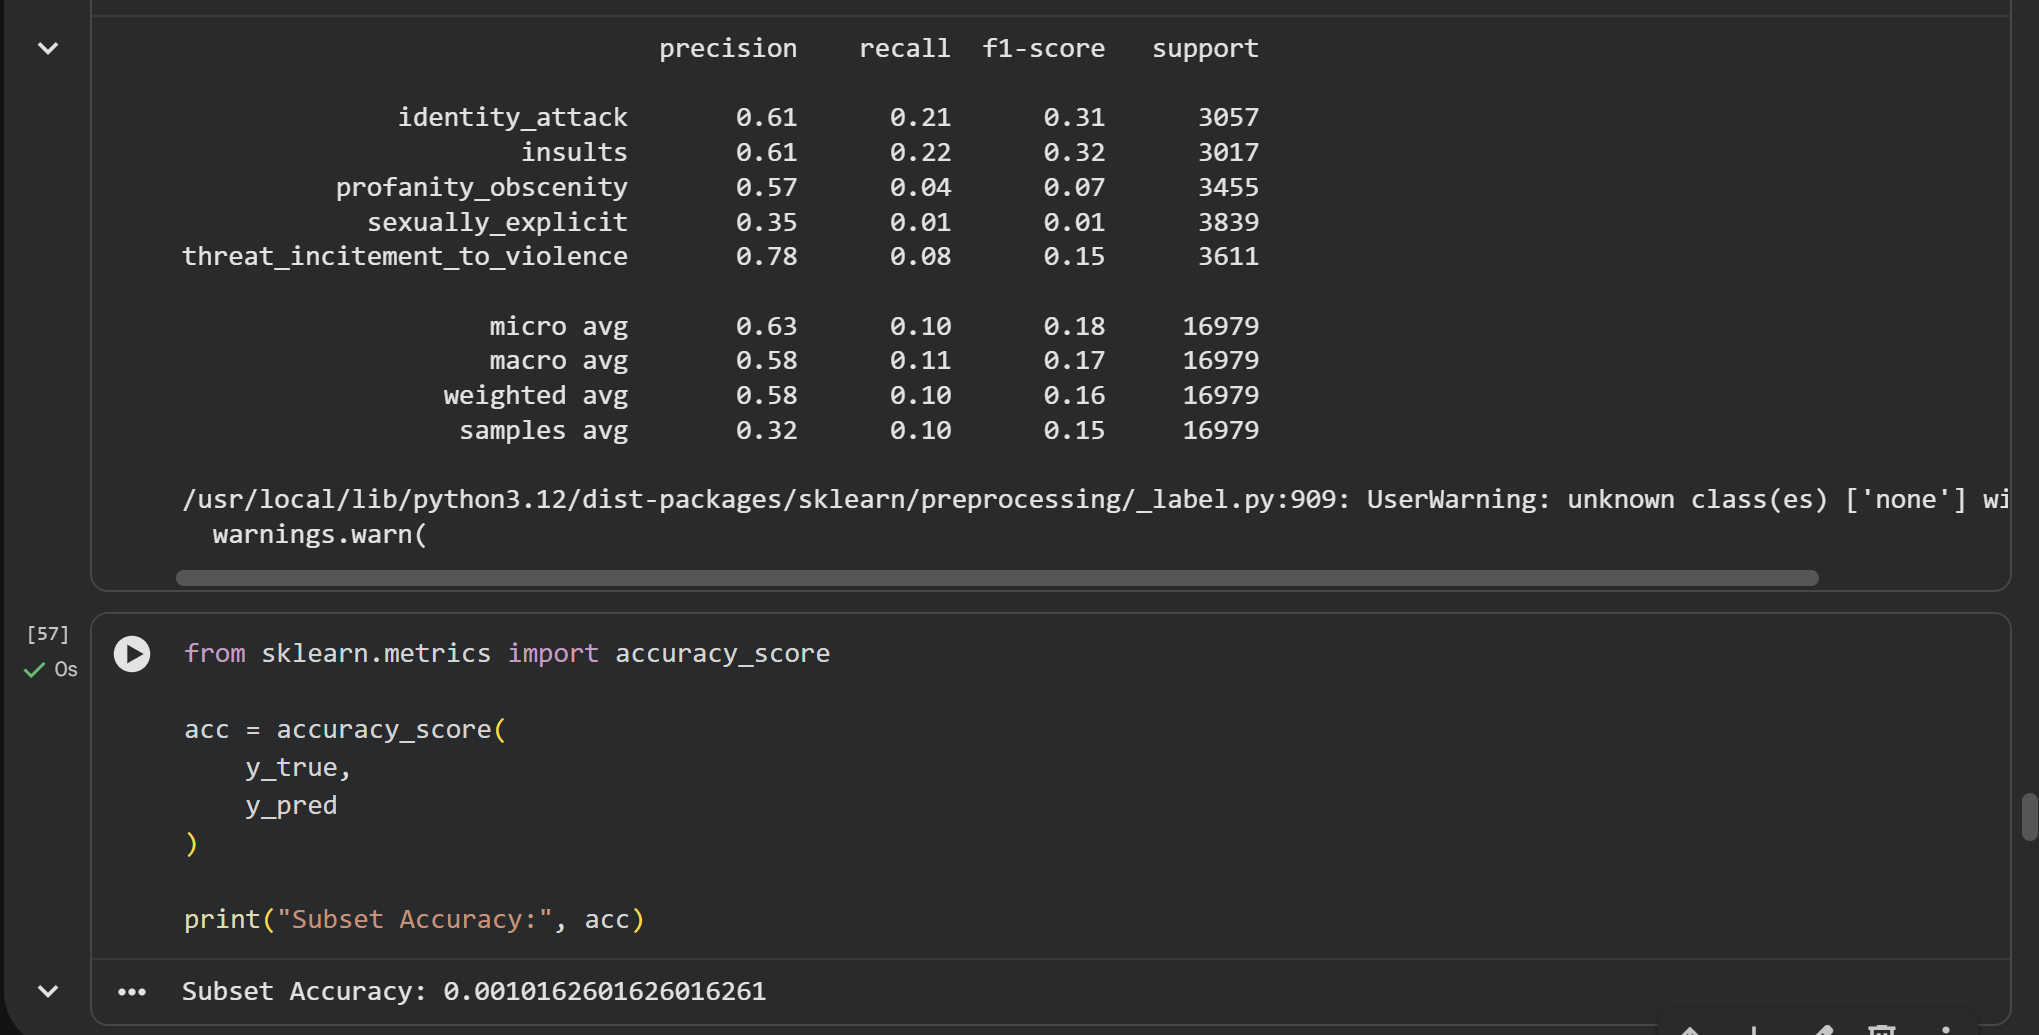
